### Plot VB index with hindcast data

In [6]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

DATADIR = "/climca/data/SEAS5_SA/data"

ds = xr.open_dataset(
    DATADIR + "/seas5_daily_u_component_wind_50hPa_AugInit.nc"
    , decode_cf=False
)

display(ds)

u=ds #['u'].sel(forecast_period=1440.0)

print("forecast_period:")
print(u["forecast_period"].values[:10])

print("\nvalid_time:")
print(u["valid_time"].values[..., :10])

print("\nvalid_time dtype:")
print(u["valid_time"].attrs)

<xarray.Dataset> Size: 6GB
Dimensions:                  (number: 51, forecast_reference_time: 42,
                              forecast_period: 91, pressure_level: 1,
                              latitude: 21, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) int64 336B 368150400 ....
  * forecast_period          (forecast_period) float64 728B 1.44e+03 ... 3.6e+03
  * pressure_level           (pressure_level) float64 8B 50.0
  * latitude                 (latitude) float64 168B -50.0 -51.0 ... -69.0 -70.0
  * longitude                (longitude) float64 3kB -180.0 -179.0 ... 179.0
Data variables:
    valid_time               (forecast_reference_time, forecast_period) float64 31kB ...
    u                        (number, forecast_reference_time, forecast_period, pressure_level, latitude, longitude) float32 6GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-02T15:20 GRIB to CDM+CF via cfgrib-0.9.1...

forecast_period:
[1440. 1464. 1488. 1512. 1536. 1560. 1584. 1608. 1632. 1656.]

valid_time:
[[3.7333440e+08 3.7342080e+08 3.7350720e+08 3.7359360e+08 3.7368000e+08
  3.7376640e+08 3.7385280e+08 3.7393920e+08 3.7402560e+08 3.7411200e+08]
 [4.0487040e+08 4.0495680e+08 4.0504320e+08 4.0512960e+08 4.0521600e+08
  4.0530240e+08 4.0538880e+08 4.0547520e+08 4.0556160e+08 4.0564800e+08]
 [4.3640640e+08 4.3649280e+08 4.3657920e+08 4.3666560e+08 4.3675200e+08
  4.3683840e+08 4.3692480e+08 4.3701120e+08 4.3709760e+08 4.3718400e+08]
 [4.6802880e+08 4.6811520e+08 4.6820160e+08 4.6828800e+08 4.6837440e+08
  4.6846080e+08 4.6854720e+08 4.6863360e+08 4.6872000e+08 4.6880640e+08]
 [4.9956480e+08 4.9965120e+08 4.9973760e+08 4.9982400e+08 4.9991040e+08
  4.9999680e+08 5.0008320e+08 5.0016960e+08 5.0025600e+08 5.0034240e+08]
 [5.3110080e+08 5.3118720e+08 5.3127360e+08 5.3136000e+08 5.3144640e+08
  5.3153280e+08 5.3161920e+08 5.3170560e+08 5.3179200e+08 5.3187840e+08]
 [5.6263680e+08 5.6272320e+08 5.628096

In [5]:
def prepare_u60S(u):
    u_zonal = u.mean(dim="longitude")

    u_60S = u_zonal.interp(latitude=-60)

    if "pressure_level" in u_60S.dims:
        u_60S = u_60S.squeeze("pressure_level", drop=True)

    return u_60S

In [6]:
def smooth_forecast_period(u_60S, window=5):
    return u_60S.rolling(forecast_period=window, center=True).mean()

In [7]:
def _find_breakdown_doy_1d(u_values, valid_times, threshold=10.0, crossing="last"):
    ok = np.isfinite(u_values)

    if ok.sum() == 0:
        return np.nan

    below = (u_values < threshold) & ok

    previous_below = np.roll(below, 1)
    previous_below[0] = False

    crossed = below & (~previous_below)

    idx = np.where(crossed)[0]

    if len(idx) == 0:
        return np.nan

    if crossing == "first":
        i = idx[0]
    elif crossing == "last":
        i = idx[-1]
    else:
        raise ValueError("crossing must be 'first' or 'last'")

    date = pd.Timestamp(valid_times[i])
    return float(date.dayofyear)

In [8]:
# breakdown_doy = compute_vortex_breakdown_doy(
#     u,
#     threshold=10.0,
#     window=5,
#     crossing="last",
# ).compute()

# print(breakdown_doy)

In [5]:
data_era5 = pd.read_csv('/climca/people/glattus/data_ready/data_ready/6_with_IOBW_VB.csv')

In [6]:
data_era5.head()

,Unnamed: 0,t_LaPlata,precip_LaPlata,ENSO,IOD,EDJ,EDJ_lat,EDJ_lat_nostd,SPV,A_SAM,S_SAM,IOBW,VB,VB_class
0,1951,-1.180512,1.302884,-0.686614,0.255515,1.782753,-0.698485,-52.071429,0.263327,0.233046,0.603790,-1.546450,-0.065298,Early
1,1952,-0.648889,1.122124,0.583825,0.628088,0.667732,1.358745,-48.642857,-0.631221,-1.135330,-1.058408,0.859070,-0.100988,Early
2,1953,1.827087,-1.184538,0.306847,1.259803,-0.505639,-0.955639,-52.500000,1.450647,-2.197377,0.143728,-0.337411,0.224743,Late
3,1954,0.065156,0.259239,0.514070,0.028294,1.655904,1.101591,-49.071429,-0.003821,0.297990,-0.323217,0.982053,0.034158,Early
4,1955,0.848021,0.378231,-0.809030,-1.107809,0.825751,0.072976,-50.785714,0.748067,-0.615178,-0.057973,-0.238466,0.127547,Early


array([282., 283., 286., 288., 290., 296., 299., 300., 301., 302., 303.,
       304., 305., 306., 307., 308., 309., 310., 311., 312., 313., 314.,
       315., 316., 317., 318., 319., 320., 321., 322., 323., 324., 325.,
       326., 327., 328., 329., 330., 331., 332., 333., 334., 335., 336.,
       337., 338., 339., 340., 341., 342., 343., 344., 345., 346., 347.,
       348., 349., 350., 351., 352., 353., 354., 355., 356., 357., 358.,
       359., 360., 361., 362.,  nan])

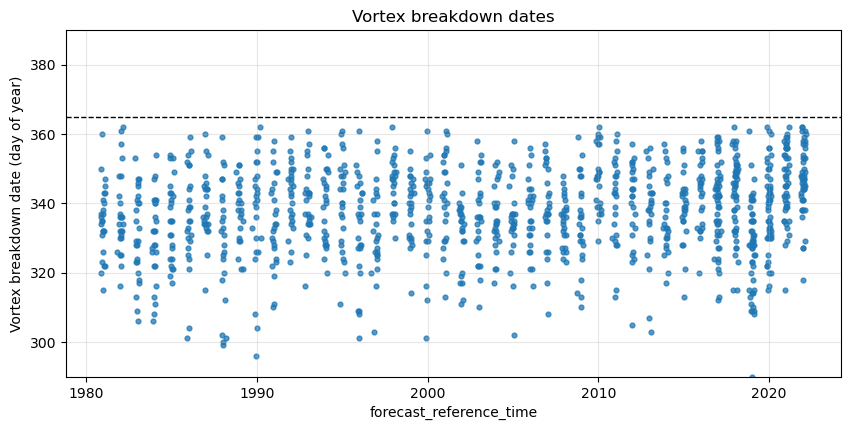

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/climca/people/glattus/Hindcast_data_ready/SEAS5_VortexBreakdown_DOY_Aug.csv')
data2 = pd.read_csv('/climca/people/glattus/Hindcast_data_ready/SEAS5_VortexBreakdown_DOY_Sep.csv')
display(np.unique(data2['VB_DOY']))
VB = np.nanmean(data2['VB_DOY'])
df = data2

df["forecast_reference_time"] = pd.to_datetime(df["forecast_reference_time"])
df["year"] = df["forecast_reference_time"].dt.year

rng = np.random.default_rng(0)
df["year_jitter"] = df["year"] + rng.normal(0, 0.08, size=len(df))

plt.figure(figsize=(10, 4.5))

plt.scatter(
    df["year_jitter"],
    df["VB_DOY"],
    s=12,
    alpha=0.75
)

plt.axhline(365, linestyle="--", color="black", linewidth=1)

plt.ylim(290, 390)

plt.xlabel("forecast_reference_time")
plt.ylabel("Vortex breakdown date (day of year)")
plt.title("Vortex breakdown dates")

plt.grid(alpha=0.3)
plt.show()

,number,forecast_reference_time,latitude,VB_DOY
0,0,1981-09-01,-60,338.0
1,0,1982-09-01,-60,340.0
2,0,1983-09-01,-60,342.0
3,0,1984-09-01,-60,322.0
4,0,1985-09-01,-60,322.0
...,...,...,...,...
2137,50,2018-09-01,-60,375.0
2138,50,2019-09-01,-60,325.0
2139,50,2020-09-01,-60,361.0
2140,50,2021-09-01,-60,342.0


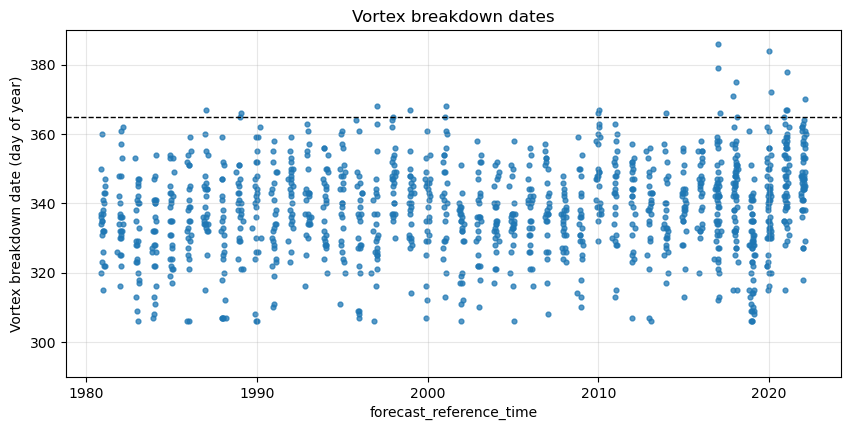

In [3]:

data = pd.read_csv('/climca/people/glattus/Hindcast_data_ready/SEAS5_VortexBreakdown_DOY_Aug.csv')
VB = np.mean(data['VB_DOY'])
df = data
display(df)
df["forecast_reference_time"] = pd.to_datetime(df["forecast_reference_time"])
df["year"] = df["forecast_reference_time"].dt.year

rng = np.random.default_rng(0)
df["year_jitter"] = df["year"] + rng.normal(0, 0.08, size=len(df))

plt.figure(figsize=(10, 4.5))

plt.scatter(
    df["year_jitter"],
    df["VB_DOY"],
    s=12,
    alpha=0.75
)

plt.axhline(365, linestyle="--", color="black", linewidth=1)

plt.ylim(290, 390)

plt.xlabel("forecast_reference_time")
plt.ylabel("Vortex breakdown date (day of year)")
plt.title("Vortex breakdown dates")

plt.grid(alpha=0.3)
plt.show()

   year        VB  VB_DOY_mean_all_members
0  1951 -0.065298               337.712605
1  1952 -0.100988               337.712605
2  1953  0.224743               337.712605
3  1954  0.034158               337.712605
4  1955  0.127547               337.712605


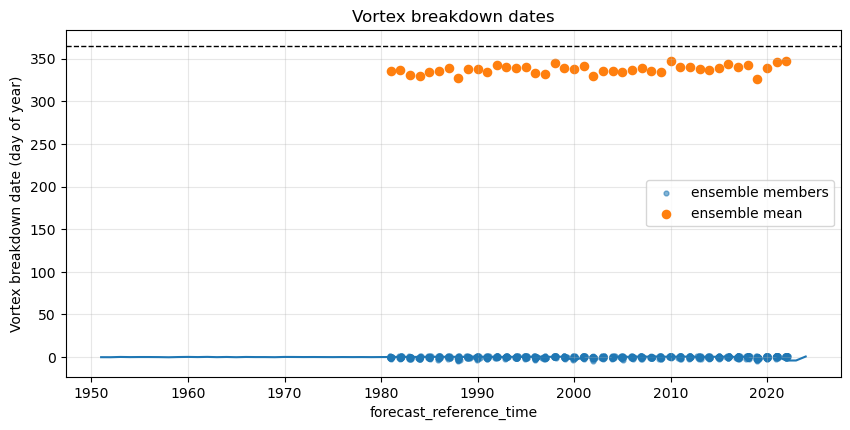

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def standardize(x):
    return (x-np.mean(x))/np.std(x)


# Scatter data: 51 members x years
vb_scatter = data2
vb_scatter["forecast_reference_time"] = pd.to_datetime(vb_scatter["forecast_reference_time"])
vb_scatter["year"] = vb_scatter["forecast_reference_time"].dt.year

# Other data
other = data_era5

# keep only year and VB
other = other.rename(columns={"Unnamed: 0": "year"})
other_vb = other[["year", "VB"]].copy()

# add mean value of the hindcast VB_DOY scatters
other_vb["VB_DOY_mean_all_members"] = np.mean(vb_scatter["VB_DOY"])

print(other_vb.head())

# mean of scatters for each year
vb_mean_year = (
    vb_scatter
    .groupby("year", as_index=False)["VB_DOY"]
    .mean()
    .rename(columns={"VB_DOY": "VB_DOY_ens_mean"})
)

# plot
rng = np.random.default_rng(0)
vb_scatter["year_jitter"] = vb_scatter["year"] + rng.normal(0, 0.08, size=len(vb_scatter))

plt.figure(figsize=(10, 4.5))

plt.plot(other_vb["year"],other_vb["VB"])

plt.scatter(
    vb_scatter["year_jitter"],
    standardize(vb_scatter["VB_DOY"]),
    s=12,
    alpha=0.55,
    label="ensemble members"
)

# plt.scatter(
#      vb_mean_year["year"],
#      vb_mean_year["VB_DOY_ens_mean"],
#      s=35,
#      label="ensemble mean"
#  )

#plt.axhline(365, linestyle="--", color="black", linewidth=1)


plt.xlabel("forecast_reference_time")
plt.ylabel("Vortex breakdown date (day of year)")
plt.title("Vortex breakdown dates")

plt.grid(alpha=0.3)
plt.legend()
plt.show()